**Importing Libraries**

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow


**Importing Image**

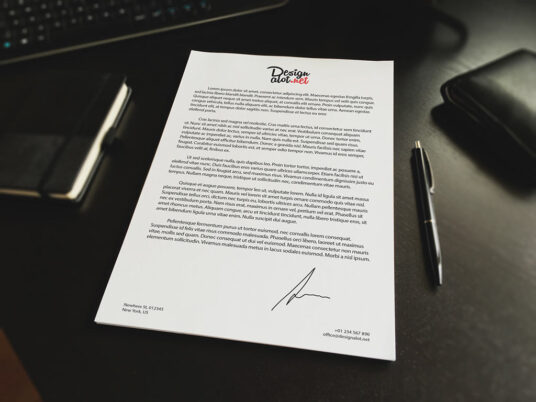

Image shape: (402, 536, 3)


In [2]:
image = cv2.imread("/content/image1.jpg")
cv2_imshow(image)
print("Image shape:", image.shape)

Stage 0: Resizing the image

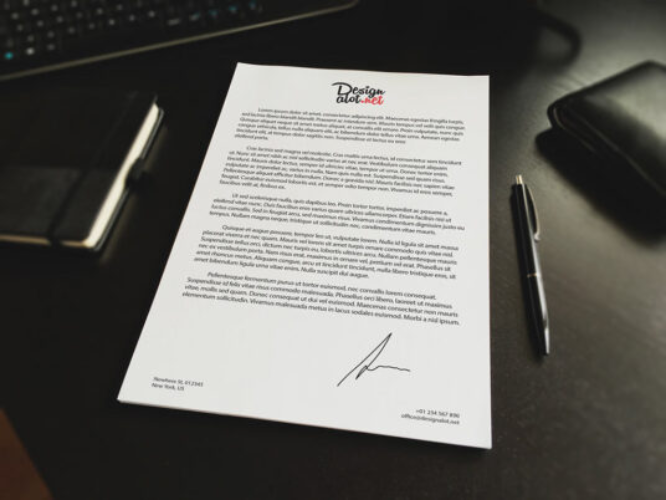

Image shape: (500, 666, 3)


In [3]:
def resizeImage(image, show=0):
  ratio = image.shape[0] / 500.0
  if show == 1:
    cv2_imshow((cv2.resize(image, (int(image.shape[1] / ratio), 500))))
  return cv2.resize(image, (int(image.shape[1] / ratio), 500))

resized = resizeImage(image, show=1)
print("Image shape:", resized.shape)

**Stage 1: Converting RBG image to Grayscale image**

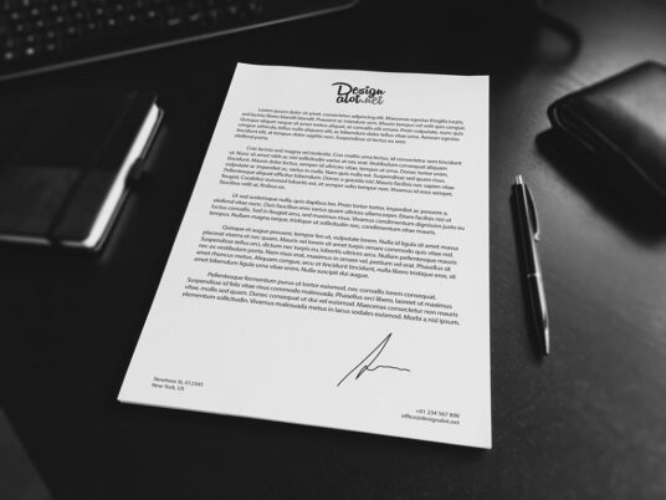

Image shape: (500, 666)


In [4]:
def applyGrayscale(image, show=0):
  if show == 1:
    cv2_imshow((cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)))
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray = applyGrayscale(resized, show=1)
print("Image shape:", gray.shape)

**Stage 2: Applying blur to the image to remove the noise**

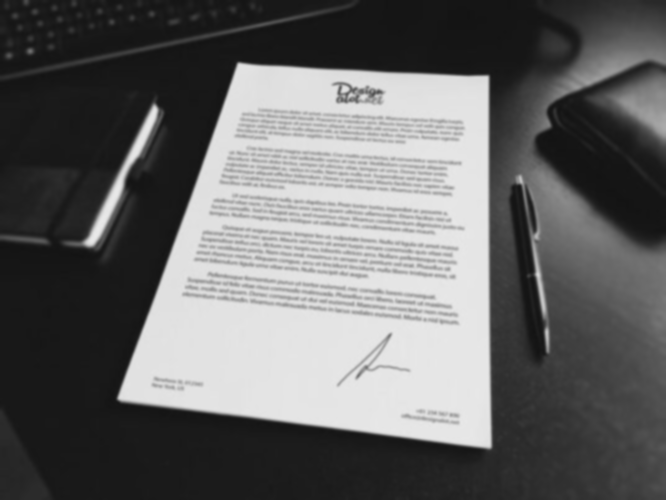

Image shape: (500, 666)


In [5]:
def applyGaussianBlur(image, kernel=5, show=0):
  if show == 1:
    cv2_imshow((cv2.GaussianBlur(image, (kernel, kernel), 0)))
  return cv2.GaussianBlur(image, (kernel, kernel), 0)

blurred = applyGaussianBlur(gray, kernel=5, show=1)
print("Image shape:", blurred.shape)

**Stage 3: Finding the edge using Canny**

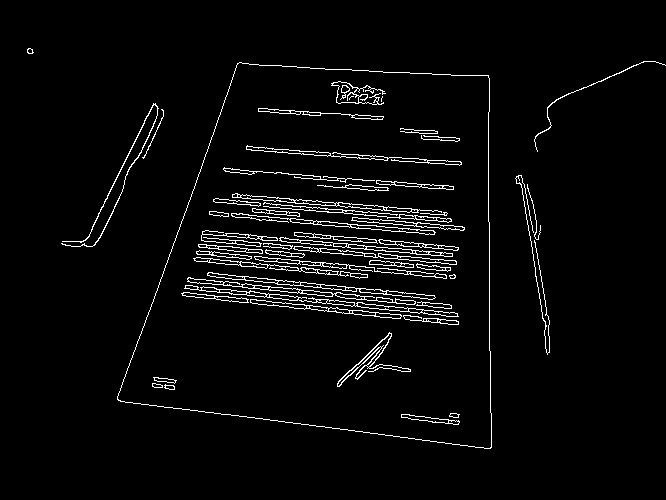

Image shape: (500, 666)


In [6]:
def applyCanny(image, low_threshold=75, high_threshold=200, show=0):
  if show == 1:
    cv2_imshow((cv2.Canny(image, low_threshold, high_threshold)))
  return cv2.Canny(image, low_threshold, high_threshold)
edged = applyCanny(blurred, show=1)
print("Image shape:", edged.shape)

**Stage 4: Finding the closed 4 point contours**

In [7]:
contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
#sorting the area to top 5 only
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

#finding the 4 point contour
screenCnt = None
for c in contours:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
        screenCnt = approx
        break

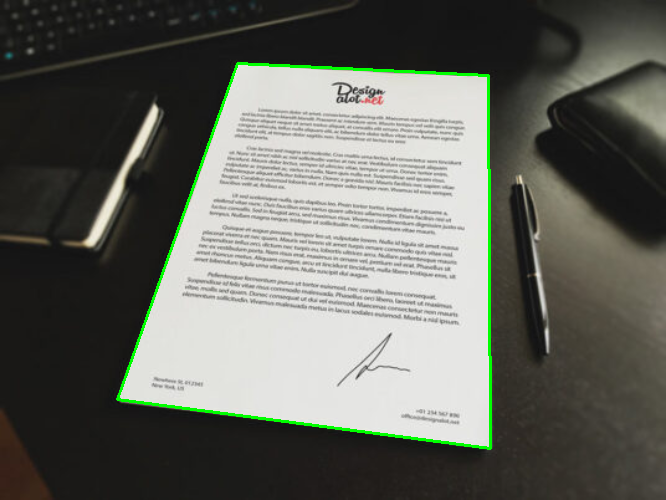

Document found!


In [8]:
if screenCnt is not None:
    cv2.drawContours(resized, [screenCnt], -1, (0, 255, 0), 2)
    cv2_imshow(resized)
    print("Document found!")
else:
    print("No document found. Try adjusting Canny thresholds.")

**Stage 5: Ordering the points into TL, TR, BL, BR and finding the Warp**

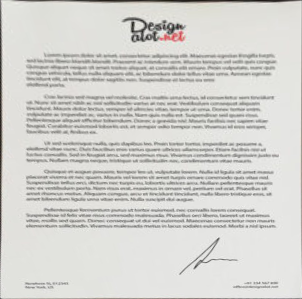

In [9]:
ratio = image.shape[0] / 500.0
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left
    rect[2] = pts[np.argmax(s)]   # bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left

    return rect

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Compute output width
    widthA  = np.sqrt(((br[0]-bl[0])**2) + ((br[1]-bl[1])**2))
    widthB  = np.sqrt(((tr[0]-tl[0])**2) + ((tr[1]-tl[1])**2))
    maxWidth = max(int(widthA), int(widthB))

    # Compute output height
    heightA = np.sqrt(((tr[0]-br[0])**2) + ((tr[1]-br[1])**2))
    heightB = np.sqrt(((tl[0]-bl[0])**2) + ((tl[1]-bl[1])**2))
    maxHeight = max(int(heightA), int(heightB))

    # Destination points (perfect rectangle)
    dst = np.array([
        [0,          0],
        [maxWidth-1, 0],
        [maxWidth-1, maxHeight-1],
        [0,          maxHeight-1]
    ], dtype="float32")

    # Compute and apply warp
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    return warped

# Apply on original full resolution image
warped = four_point_transform(image, screenCnt.reshape(4, 2) * ratio)
cv2_imshow(warped)

**Stage 6: Doing adaptive thresold on the wrap image**

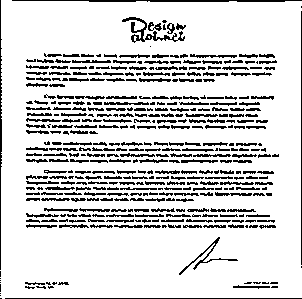

In [10]:
wraped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
scanned = cv2.adaptiveThreshold(wraped_gray,
                                255,
                                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY,
                                11,
                                10)
cv2_imshow(scanned)